# İş Akışı ve Hiperparametre Optimizasyonu

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

🏠 Ev fiyatları veri setini içe aktarın. Basitlik adına sadece sayısal özellikleri tutacağız

🎯 Hedefiniz en iyi KNN Regressor'ı yerleştirmek olacak. Özellikle, ev fiyatlarınız için en iyi tahminleri elde etmek üzere kaç tane "komşu" (<font color=blue>K</font>NN'deki <font color=blue>K</font>) göz önünde bulundurmalısınız?

In [2]:
# Load raw data
data = pd.read_csv('https://d32aokrjazspmn.cloudfront.net/materials/houses_train_raw.csv', index_col="Id")

# Only keep numerical columns and raws without NaN
data = data.select_dtypes(include=np.number).dropna()

data

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
2,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
3,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
4,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
5,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,0,40,0,0,0,0,0,8,2007,175000
1457,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,349,0,0,0,0,0,0,2,2010,210000
1458,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,0,60,0,0,0,0,2500,5,2010,266500


In [3]:
X = data.drop(columns=['SalePrice'])
y = data['SalePrice']

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1121 entries, 1 to 1460
Data columns (total 37 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1121 non-null   int64  
 1   LotFrontage    1121 non-null   float64
 2   LotArea        1121 non-null   int64  
 3   OverallQual    1121 non-null   int64  
 4   OverallCond    1121 non-null   int64  
 5   YearBuilt      1121 non-null   int64  
 6   YearRemodAdd   1121 non-null   int64  
 7   MasVnrArea     1121 non-null   float64
 8   BsmtFinSF1     1121 non-null   int64  
 9   BsmtFinSF2     1121 non-null   int64  
 10  BsmtUnfSF      1121 non-null   int64  
 11  TotalBsmtSF    1121 non-null   int64  
 12  1stFlrSF       1121 non-null   int64  
 13  2ndFlrSF       1121 non-null   int64  
 14  LowQualFinSF   1121 non-null   int64  
 15  GrLivArea      1121 non-null   int64  
 16  BsmtFullBath   1121 non-null   int64  
 17  BsmtHalfBath   1121 non-null   int64  
 18  FullBath     

## 1. Eğitim/Test Ayrımı

❓ **Soru (Holdout)**❓

👇 `X_train`, `X_test`, `y_train` ve `y_test` oluşturmak için veri setini böl. Şunları kullan:
- `test_size=0.3`
- Sonuçlarınızı arkadaşınızla karşılaştırmak için `random_state=0`

In [5]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=0
)

## 2. Ölçeklendirme

⚖️ Ölçeklendirme KNN algoritması için her zaman kritik derecede önemlidir..

❓ **Soru (Ölçeklendirme)** ❓ 

* Eğitim setinizi ve test setinizi ölçeklendirin.
* Burada, basitçe `StandardScaler` uygulayalım ve özellik başına bir ölçekleyici seçerek zaman kaybetmeyelim. Gerçekten de, bu egzersizin amaçları şunlardır:
    * KNN'i gözden geçirmek
    * GridSearchCV'yi anlamak
    * RandomizedSearchCV'yi anlamak

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [7]:
X_test_scaled = scaler.transform(X_test)

In [8]:
X_train_scaled[:5] 

array([[-0.87871936,  0.18688486, -0.06663489, -0.15983839,  1.35789455,
        -0.4458862 , -1.3144622 ,  0.10820427,  0.32695021, -0.2785544 ,
        -0.20764858,  0.02224128, -0.22942173, -0.81404509, -0.11287779,
        -0.86695612, -0.80565486, -0.22569523, -1.05755035, -0.78136577,
         0.20701068, -0.19641114, -1.01135211, -0.96234726, -0.81266841,
        -1.3489727 , -1.15113012, -0.73893854, -0.74948391, -0.37256572,
        -0.10995352,  2.19599277, -0.06167325, -0.14608468, -0.11071095,
         0.16828509],
       [-0.87871936,  2.10800891,  0.11718506, -0.87184579,  0.4157801 ,
         0.09348313, -0.5075742 , -0.58415654,  0.65978279, -0.2785544 ,
        -0.77136047, -0.24052343, -0.52757884, -0.81404509, -0.11287779,
        -1.08024185, -0.80565486, -0.22569523, -1.05755035,  1.22712853,
         0.20701068, -0.19641114, -1.01135211, -0.96234726, -0.14629431,
         0.15757231, -0.35292536, -0.73893854, -0.74948391, -0.37256572,
        -0.10995352, -0.27792

## 3. Temel KNN modeli

❓ **Soru (KNN için bir temel)** ❓

Sadece _en yakın komşuyu_ dikkate alan basit bir KNN regressor'ı çapraz doğrulayın (*cv = 5*) ve 5 kat üzerindeki ortalama skoru hesaplayın.

In [9]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score

knn_1 = KNeighborsRegressor(n_neighbors=1)

scores = cross_val_score(
    knn_1,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error")


score_mean= scores.mean()


In [10]:
scores

array([-55801.39730358, -42152.6305844 , -76517.67413497, -40626.82189765,
       -61799.5371219 ])

In [11]:
score_mean

-55379.61220849835

## 4. GridSearch

### 4.1. İlk GridSearch

❓ **Soru (GridSearch v1)**❓

En iyi KNN hiperparametresini `n_neighbors` bulmak için SKLearn `GridSearchCV` kullanalım.
- `n_neighbors` = [1,5,10,20,50] ile kaba taneli bir yaklaşım başlat
- Her parametreyi 5-kat çapraz doğrula
- `n_jobs` kullanarak performans sürenizi maksimize ettiğinizden emin olun

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor

# Instantiate model
knn = KNeighborsRegressor()

# Hyperparameter Grid
param_grid = {
    "n_neighbors": [1, 5, 10, 20, 50]
}

# Instantiate Grid Search
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Fit data to Grid Search
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'n_neighbors': [1, 5, 10, 20, 50]}, scoring='r2')

❓ **Soru (en iyi parametreler)** ❓

GridSearch'e göre, optimal K değeri nedir?

In [13]:
grid_search.best_params_

{'n_neighbors': 10}

❓ **Soru (puanlama)** ❓ Optimal K değerinin ürettiği en iyi skor nedir?

In [14]:
grid_search.best_score_

0.7596697382171873

### 4.2. İkinci GridSearch

❓ **Soru (GridSearch V2)** ❓

Şimdi, en iyi $K$'nın nerede olduğu hakkında bir fikrimiz var, ancak denemediğimiz bazı değerler daha iyi bir performansla sonuçlanabilir.

* Önceki en iyi değerinizin çevresindeki $K$ için bazı değerleri deneyerek GridSearch'ü yeniden çalıştırın
* Bu rafine edilmiş GridSearch için `best_score` ve `best_k` nelerdir?

In [15]:
# Instantiate model
knn = KNeighborsRegressor()

# Hyperparameter Grid
param_grid_v2 = {
    "n_neighbors": [7, 8, 9, 10, 11, 12, 13]
}

# Instantiate Grid Search
grid_search_v2 = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_v2,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Fit data to Grid Search
grid_search_v2.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'n_neighbors': [7, 8, 9, 10, 11, 12, 13]},
             scoring='r2')

In [18]:
best_k = grid_search_v2.best_params_["n_neighbors"]
best_score = grid_search_v2.best_score_

print("Best k (v2):", best_k)
print("Best CV RMSE (v2):", -best_score)

Best k (v2): 13
Best CV RMSE (v2): -0.7628734645391733


***🧪 Kodunuzu test edin***

In [19]:
from nbresult import ChallengeResult
result = ChallengeResult('knn',
                         best_k=best_k,
                         best_score=best_score)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/seval/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/seval/workintech/week_16/D16D5-S-data-workflow/tests
plugins: anyio-4.8.0, dash-4.1.0, typeguard-4.4.2
collecting ... collected 2 items

test_knn.py::TestKnn::test_best_k PASSED                                 [ 50%]
test_knn.py::TestKnn::test_best_score PASSED                             [100%]

============================== 2 passed in 0.28s ===============================


💯 You can commit your code:

git add tests/knn.pickle

git commit -m 'Completed knn step'

git push origin master



### 4.3. Görsel kontrol (manuel GridSearch)

☝️ Bu problem aslında manuel olarak GridSearch yapmak için yeterince basittir.

❓ **Soru(Manuel GridSearch)** ❓

- $K$'nın $1$'den $50$'ye kadar tüm değerleri üzerinde manuel olarak döngü yapın ve her modelin çapraz doğrulanmış skorlarının ortalamasını bir listede saklayın.
- `Dirsek Yöntemi` kullanarak en iyi $K$'yı görsel olarak bulmak için skorları $K$'nın bir fonksiyonu olarak çizin

In [20]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

In [21]:
k_values = range(1,31)
mean_cv_scores = []

In [22]:
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    
    scores = cross_val_score(
        knn,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="r2"
    )
    
    mean_cv_scores.append(scores.mean())

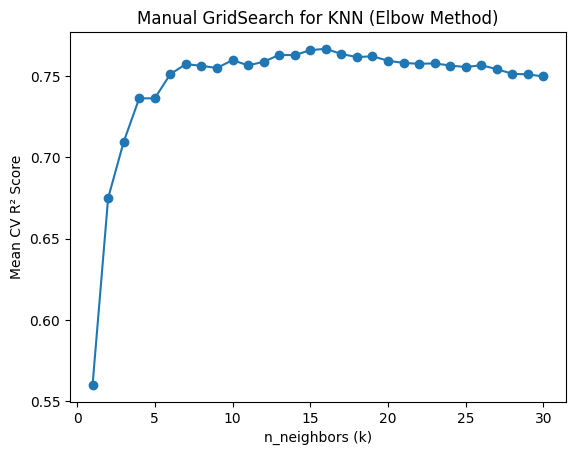

In [23]:
plt.figure()
plt.plot(k_values, mean_cv_scores, marker="o")
plt.xlabel("n_neighbors (k)")
plt.ylabel("Mean CV R² Score")
plt.title("Manual GridSearch for KNN (Elbow Method)")
plt.show()

❓GridSearchCV'yi böyle bir manuel döngüden daha iyi bir seçenek yapan şeyi tahmin edebilir misiniz?

<details>
    <summary>Cevap</summary>

- Sklearn'ın `n_jobs=-1` seçeneği aramayı paralelleştirmenize izin verir, tüm CPU çekirdeklerinizi kullanır
- Birlikte optimize edilecek birden fazla hiperparametreniz olsaydı ne olurdu?
</details>

## 5. Birden çok parametre ile GridSearch

👩🏻‍🏫 KNNRegressor, `p` hiperparametresi aracılığıyla çeşitli _mesafe metrikleri_ destekler

📚 [sklearn.neighbors.KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html)

❓ **Soru (birden çok parametreyi ayarlama)** ❓

* En iyi $K$ ve $p$'yi aynı anda aramak için GridSearchCV kullanın.
    * $K = [1, 5, 10, 20, 50]$ ve $p = [1, 2, 3]$ için tüm kombinasyonları deneyin.

In [24]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_neighbors": [1, 5, 10, 20, 30],
    "p": [1, 2, 3]
}

knn = KNeighborsRegressor()

grid_search_multi = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search_multi.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(), n_jobs=-1,
             param_grid={'n_neighbors': [1, 5, 10, 20, 30], 'p': [1, 2, 3]},
             scoring='r2')

❓ **Soru (alt model sayısı)**❓

Toplamda kaç alt model eğittiniz?

<details>
    <summary>İpucu</summary>

15'ten çok daha fazla. İki kez düşün :)
    <details>
    <summary>Cevap</summary>

CV=5 nedeniyle 75 model
</details>

In [ ]:
5*3*5 = 75

❓ **Soru (modeli birden çok parametre ile ayarladıktan sonra en iyi parametreler ve en iyi skor)**❓

*En iyi parametreler* ve *en iyi skor* nedir?

In [25]:
best_params = grid_search_multi.best_params_
best_score = grid_search_multi.best_score_

print("Best parameters:", best_params)
print("Best CV R² score:", best_score)

Best parameters: {'n_neighbors': 10, 'p': 1}
Best CV R² score: 0.7969255879201194


## 6. Rastgele Arama

Şimdi bir RandomizedSearch'ün aynı sayıda model yerleştirilerek daha iyi bir kombinasyon bulup bulamayacağını görelim.

❓ **Soru (RandomizedSearchCV)** ❓

`RandomizedSearchCV` kullanarak
- $K$'yı uniform `scipy.stats.randint(1,50)` ([döküman](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.randint.html)) dağılımından rastgele örnekle
- $p$'yi $[1,2,3]$ listesinden örnekle
- Önceki GridSearchCV'nizdeki ile tam olarak aynı sayıda model yerleştirmek için doğru `n_iter` ve `cv` sayılarını kullanın.

In [26]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distributions = {
    "n_neighbors": randint(1, 50),  # uniform integer [1, 50)
    "p": [1, 2, 3]
}

knn = KNeighborsRegressor()

random_search = RandomizedSearchCV(
    estimator=knn,
    param_distributions=param_distributions,
    n_iter=15,          # 🔥 kritik
    cv=5,               # 🔥 kritik
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_scaled, y_train)

RandomizedSearchCV(cv=5, estimator=KNeighborsRegressor(), n_iter=15, n_jobs=-1,
                   param_distributions={'n_neighbors': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c7107ea4710>,
                                        'p': [1, 2, 3]},
                   random_state=42, scoring='r2')

In [27]:
best_params_rs = random_search.best_params_
best_score_rs = random_search.best_score_

print("Best parameters (RandomizedSearch):", best_params_rs)
print("Best CV R² score:", best_score_rs)

Best parameters (RandomizedSearch): {'n_neighbors': 8, 'p': 1}
Best CV R² score: 0.7942356840941323


## 7. Genelleme

❓ **Soru (modelinizi bir kez daha ince ayarlama)**❓

- İsterseniz RandomsearchCV'nizi rafine edin
- En iyi modelinizi seçin

In [28]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.neighbors import KNeighborsRegressor

param_distributions_refined = {
    "n_neighbors": randint(5, 15),  # 8 çevresi
    "p": [1, 2]
}

knn = KNeighborsRegressor()

random_search_refined = RandomizedSearchCV(
    knn,
    param_distributions=param_distributions_refined,
    n_iter=20,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

random_search_refined.fit(X_train_scaled, y_train)

RandomizedSearchCV(cv=5, estimator=KNeighborsRegressor(), n_iter=20, n_jobs=-1,
                   param_distributions={'n_neighbors': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c7107761af0>,
                                        'p': [1, 2]},
                   random_state=42, scoring='r2')

Şimdi `cv_results`'ınızı bir `DataFrame` olarak görüntülemeye çalışın, bu CV'nin içinde neler olup bittiğini görselleştirmenize yardımcı olacak! 😉

In [29]:
best_model = random_search_refined.best_estimator_

best_params = random_search_refined.best_params_
best_score = random_search_refined.best_score_

best_params, best_score

({'n_neighbors': 9, 'p': 1}, 0.7974801437687364)

In [30]:
import pandas as pd

cv_results_df = pd.DataFrame(random_search_refined.cv_results_)
cv_results_df.sort_values("mean_test_score", ascending=False).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,param_p,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
2,0.002425,0.000558,0.003863,0.000097,9,1,"{'n_neighbors': 9, 'p': 1}",0.762593,0.823336,0.741549,0.867283,0.792639,0.797480,0.044519,1
18,0.000741,0.000110,0.002927,0.000055,9,1,"{'n_neighbors': 9, 'p': 1}",0.762593,0.823336,0.741549,0.867283,0.792639,0.797480,0.044519,1
11,0.000730,0.000107,0.002963,0.000135,9,1,"{'n_neighbors': 9, 'p': 1}",0.762593,0.823336,0.741549,0.867283,0.792639,0.797480,0.044519,1
8,0.000874,0.000397,0.002970,0.000231,10,1,"{'n_neighbors': 10, 'p': 1}",0.764654,0.821320,0.733358,0.866147,0.799148,0.796926,0.045769,4
19,0.000708,0.000045,0.002729,0.000232,11,1,"{'n_neighbors': 11, 'p': 1}",0.762816,0.815302,0.726084,0.862879,0.795986,0.792613,0.046427,5


❓ **Soru ("En iyi" modelin değerlendirmesi)** ❓

* "En iyi parametrelerle" modelimizin **görülmemiş** test seti `X_test` üzerindeki performansını keşfetme zamanı geldi.
    * Test seti için r2 skorunu hesaplayın ve `r2_test` olarak kaydedin.

In [ ]:
# YOUR CODE HERE

❓ **Soru (Bir adım geri çekilme)** ❓

Optimize edilmiş modelin iyi genelleme yaptığını düşünür müsünüz?

<details><summary>Cevap</summary>

Test skoru eğitim seti ile biraz azalabilir. Muhtemelen %5'ten fazla değil. Bunun nedeni şunlar olabilir:
- Temsili olmayan bir eğitim/test bölünmesi
- Model ayarlama aşamasında aşırı öğrenmeye yol açan çok küçük bir çapraz doğrulama sayısı. Ne kadar çok çapraz doğrulama yaparsanız, bulgularınız o kadar güçlü genelleşir - ancak veri setiniz çok küçükse cv'yi çok fazla artıramazsınız çünkü her katmanda temsili olmak için yeterli gözlemi tutamazsınız.
- Veri setimiz çok küçük ve hiperparametre optimizasyonumuz bu nedenle eğitim/test bölünmemize son derece bağımlı (ve aşırı uyum gösteriyor). Veri setinizin denediğiniz toplam hiperparametre kombinasyonu sayısından çok daha büyük olduğundan her zaman emin olun!
    
</details>

***🧪 Kodunuzu test edin***

In [ ]:
from nbresult import ChallengeResult
result = ChallengeResult('r2', 
                         r2_test=r2_test)
result.write()
print(result.check())

🏁 Tebrikler! Artık GridSearchCV veya RandomizedSearchCV kullanarak bir modeli nasıl ince ayarlayacağınızı biliyorsunuz

💾 Notebook'unuzu `git add/commit/push` yapmayı unutmayın...

🚀 ... ve bir sonraki meydan okumaya geçin!